In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [4]:
# Separate features and target

X = df.drop(columns=["Loan_Approved"])
y = df["Loan_Approved"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 19)
Target shape: (1000,)


In [5]:
X.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private


In [6]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Loan_Approved, dtype: object

In [7]:
from sklearn.preprocessing import LabelEncoder

# Create a copy
model_df = df.copy()

# Encode categorical columns
categorical_columns = model_df.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    encoder = LabelEncoder()
    model_df[column] = encoder.fit_transform(model_df[column])

# Separate features and target
X = model_df.drop(columns=["Loan_Approved"])
y = model_df["Loan_Approved"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 19)
y shape: (1000,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 19)
Testing data: (200, 19)


In [9]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nTotal missing values:")
print(X_train.isnull().sum().sum())

Missing values in X_train:
Applicant_ID          34
Applicant_Income      40
Coapplicant_Income    45
Employment_Status      0
Age                   40
Marital_Status         0
Dependents            41
Credit_Score          41
Existing_Loans        39
DTI_Ratio             36
Savings               37
Collateral_Value      35
Loan_Amount           41
Loan_Term             37
Loan_Purpose           0
Property_Area          0
Education_Level        0
Gender                 0
Employer_Category      0
dtype: int64

Total missing values:
466


In [13]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values handled successfully.")

Missing values handled successfully.


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Scaling completed.")

Scaling completed.


In [15]:
import numpy as np

print("NaN in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaN in X_test_scaled:", np.isnan(X_test_scaled).sum())

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0


In [16]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_accuracy = accuracy_score(y_test, logistic_pred)

logistic_precision = precision_score(
    y_test, logistic_pred,
    average='weighted',
    zero_division=0
)

logistic_recall = recall_score(
    y_test, logistic_pred,
    average='weighted',
    zero_division=0
)

logistic_f1 = f1_score(
    y_test, logistic_pred,
    average='weighted',
    zero_division=0
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.845
Precision: 0.8018692150498858
Recall   : 0.845
F1 Score : 0.8224596111507333


In [30]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train_imputed, y_train)

dt_pred = decision_tree.predict(X_test_imputed)

# Keep probabilities for ALL classes
dt_prob = decision_tree.predict_proba(X_test_imputed)

print("Probability shape:", dt_prob.shape)

Probability shape: (200, 3)


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(
    y_test, dt_pred,
    average='weighted',
    zero_division=0
)

dt_recall = recall_score(
    y_test, dt_pred,
    average='weighted',
    zero_division=0
)

dt_f1 = f1_score(
    y_test, dt_pred,
    average='weighted',
    zero_division=0
)

dt_auc = roc_auc_score(
    y_test,
    dt_prob,
    multi_class='ovr',
    average='weighted'
)

print("Decision Tree")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-Score :", dt_f1)
print("ROC-AUC  :", dt_auc)

Decision Tree
Accuracy : 0.89
Precision: 0.845348293595138
Recall   : 0.89
F1-Score : 0.8670663078052361
ROC-AUC  : 0.8809624060150375


In [35]:
# Random Forest predictions

rf_pred = random_forest.predict(X_test_imputed)

# IMPORTANT: keep probabilities for ALL classes
rf_prob = random_forest.predict_proba(X_test_imputed)

print("rf_prob shape:", rf_prob.shape)

rf_prob shape: (200, 3)


C:\Users\TRUPTI\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\TRUPTI\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [36]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test, rf_pred,
    average='weighted',
    zero_division=0
)

rf_recall = recall_score(
    y_test, rf_pred,
    average='weighted',
    zero_division=0
)

rf_f1 = f1_score(
    y_test, rf_pred,
    average='weighted',
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob,
    multi_class='ovr',
    average='weighted'
)

print("Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

Random Forest
Accuracy : 0.9
Precision: 0.8566399286987522
Recall   : 0.9
F1-Score : 0.8772185114503815
ROC-AUC  : 0.9044473684210526


In [39]:
from sklearn.metrics import roc_auc_score


logistic_prob = logistic_model.predict_proba(X_test_scaled)


logistic_auc = roc_auc_score(
    y_test,
    logistic_prob,
    multi_class='ovr',
    average='weighted'
)

print("Logistic Regression ROC-AUC:", logistic_auc)

Logistic Regression ROC-AUC: 0.8687312030075189


In [40]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    
    "Precision": [
        logistic_precision,
        dt_precision,
        rf_precision
    ],
    
    "Recall": [
        logistic_recall,
        dt_recall,
        rf_recall
    ],
    
    "F1-Score": [
        logistic_f1,
        dt_f1,
        rf_f1
    ],
    
    "ROC-AUC": [
        logistic_auc,
        dt_auc,
        rf_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.845,0.801869,0.845,0.822460,0.868731
1,Decision Tree,0.890,0.845348,0.890,0.867066,0.880962
2,Random Forest,0.900,0.856640,0.900,0.877219,0.904447


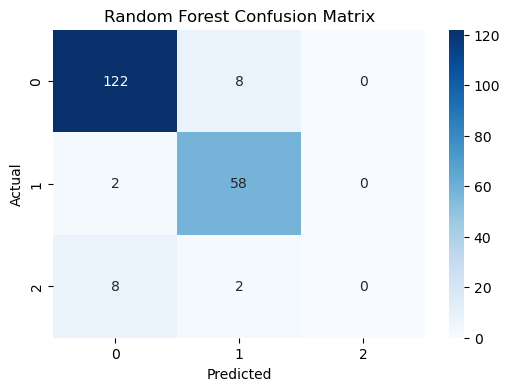

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [43]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")

print(classification_report(
    y_test,
    rf_pred,
    zero_division=0
))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       130
           1       0.85      0.97      0.91        60
           2       0.00      0.00      0.00        10

    accuracy                           0.90       200
   macro avg       0.59      0.64      0.61       200
weighted avg       0.86      0.90      0.88       200



C:\Users\TRUPTI\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


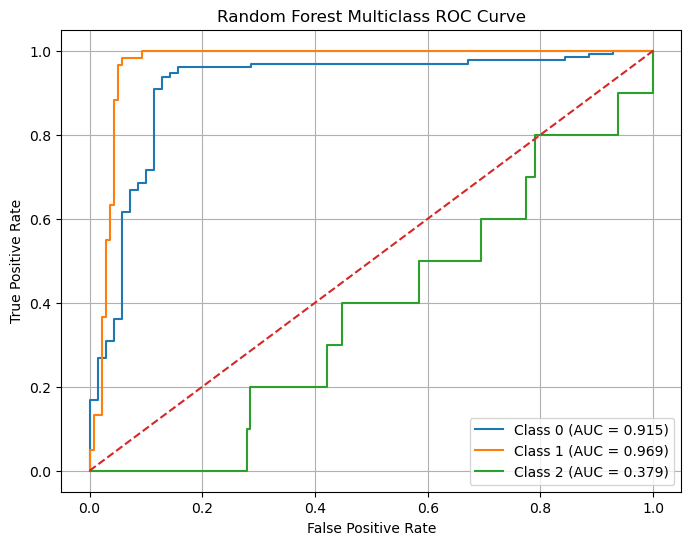

In [45]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Get the actual classes
classes = sorted(y_test.unique())

# Convert y_test to binary format for each class
y_test_bin = label_binarize(y_test, classes=classes)

# Random Forest probabilities for ALL classes
rf_prob = random_forest.predict_proba(X_test_imputed)

plt.figure(figsize=(8, 6))

# Plot ROC curve for each class
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        rf_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {class_name} (AUC = {roc_auc:.3f})"
    )

# Random guessing line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest Multiclass ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [46]:
# Feature Engineering

df["Total_Income"] = (
    df["Applicant_Income"] +
    df["Coapplicant_Income"]
)

df["Loan_to_Income"] = (
    df["Loan_Amount"] /
    (df["Total_Income"] + 1)
)

df["Savings_to_Income"] = (
    df["Savings"] /
    (df["Total_Income"] + 1)
)

df["Collateral_to_Loan"] = (
    df["Collateral_Value"] /
    (df["Loan_Amount"] + 1)
)

df["Credit_Score_sq"] = df["Credit_Score"] ** 2

df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2

df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,...,Education_Level,Gender,Employer_Category,Loan_Approved,Total_Income,Loan_to_Income,Savings_to_Income,Collateral_to_Loan,Credit_Score_sq,DTI_Ratio_sq
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,...,Not Graduate,Female,Private,No,19182.0,0.866340,1.011468,2.745969,405769.0,0.2809
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,...,Graduate,NaN,Private,No,5539.0,6.983213,0.465704,1.273573,385641.0,0.0900
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,...,NaN,Female,Government,Yes,9496.0,2.942298,1.457723,0.247209,454276.0,0.0400
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,...,Graduate,Female,Government,No,22137.0,1.256618,0.431520,0.389792,335241.0,0.0961
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,...,Graduate,Male,Private,Yes,17507.0,0.727724,0.536098,2.953147,519841.0,0.0841


In [47]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,Credit_Score,0.272725
9,DTI_Ratio,0.262726
1,Applicant_Income,0.083089
12,Loan_Amount,0.054889
10,Savings,0.040070
11,Collateral_Value,0.039918
2,Coapplicant_Income,0.039506
0,Applicant_ID,0.035875
4,Age,0.034724
13,Loan_Term,0.026370


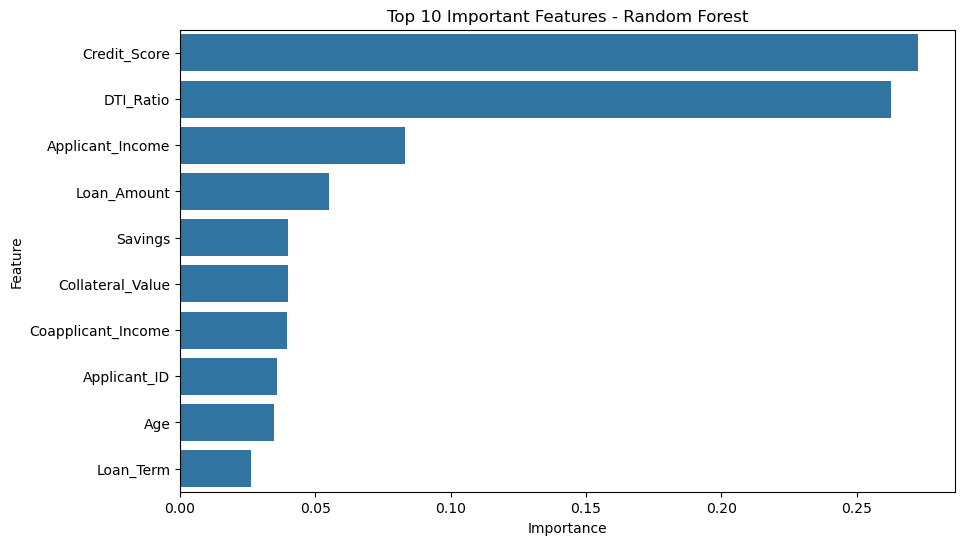

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [50]:
sample_applicant = X_test.iloc[[0]]

prediction = random_forest.predict(sample_applicant)
probability = random_forest.predict_proba(sample_applicant)[0][1]

if prediction[0] == 1:
    result = "Creditworthy / Loan Approved"
else:
    result = "Not Creditworthy / Loan Not Approved"

print("Prediction:", result)
print("Approval Probability:", round(probability * 100, 2), "%")

Prediction: Not Creditworthy / Loan Not Approved
Approval Probability: 2.02 %
